In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import MultiLabelBinarizer
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, average_precision_score, f1_score, accuracy_score

In [ ]:
training= pd.read_csv('training.csv' ,sep=';' , thousands="." )
df=pd.DataFrame(training)

In [2]:
df.dtypes
df=df.replace([np.inf, -np.inf], np.nan)
df=df.drop(2130)
df["Minuti Giocati"] = df["Minuti Giocati"].str.replace('.', '', regex=False)
mask = pd.to_numeric(df["Minuti Giocati"].str.replace('.', '', regex=False), errors='coerce').isna()
df=df.drop(df[mask].index)
df[df.select_dtypes(include=['float']).columns] = df[df.select_dtypes(include=['float']).columns].astype('Int64')
df.at[378,'Espulsioni']=np.nan
df["Espulsioni"] = df["Espulsioni"].astype('Int64')
df["Minuti Giocati"] = df["Minuti Giocati"].astype('int64')
df.dtypes
df.at[2287,'Età']=np.nan
df=df.drop(375)
df = df.reset_index(drop=True)

In [3]:
att=df.loc[df['Ruolo?'].str.contains("Att", na=False)]
cen=df.loc[df['Ruolo?'].str.contains("Cen", na=False)]
dif=df.loc[df['Ruolo?'].str.contains("Dif", na=False)]
por=df.loc[df['Ruolo?'].str.contains("Por", na=False)]

In [4]:
dataframes={
    "attaccanti": att,
    "centrocampisti": cen,
    "difensori": dif,
    "portieri": por
}

In [5]:
df.describe()

,Età,Partite Giocate,Minuti Giocati,Reti,Assist,Reti Non Su Rigore,Rigori Tirati,Ammonizioni,Espulsioni
count,2483.0,2484.0,2485.000000,2485.0,2485.0,2485.0,2485.0,2485.0,2484.0
mean,25.465969,18.93599,1206.177062,1.629779,1.130785,1.502213,0.473642,2.664789,0.122786
std,4.75177,11.890947,976.161511,3.108828,1.838541,2.771145,1.50409,2.770602,0.354222
min,14.0,1.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0
25%,22.0,8.0,287.000000,0.0,0.0,0.0,0.0,0.0,0.0
50%,25.0,20.0,1056.000000,0.0,0.0,0.0,0.0,2.0,0.0
75%,29.0,30.0,1980.000000,2.0,2.0,2.0,0.0,4.0,0.0
max,71.0,38.0,3420.000000,29.0,14.0,26.0,21.0,16.0,3.0


In [6]:
att.describe()

,Età,Partite Giocate,Minuti Giocati,Reti,Assist,Reti Non Su Rigore,Rigori Tirati,Ammonizioni,Espulsioni
count,777.0,777.0,778.000000,778.0,778.0,778.0,778.0,778.0,778.0
mean,25.155727,19.352638,1029.663239,3.332905,1.667095,3.029563,1.033419,2.025707,0.084833
std,5.072434,11.685934,867.761995,4.58928,2.20762,4.027946,2.294061,2.268776,0.301009
min,15.0,1.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0
25%,21.0,9.0,214.250000,0.0,0.0,0.0,0.0,0.0,0.0
50%,25.0,20.0,842.500000,1.0,1.0,1.0,0.0,1.0,0.0
75%,28.0,30.0,1692.000000,5.0,2.75,4.0,1.0,3.0,0.0
max,71.0,38.0,3323.000000,29.0,14.0,26.0,21.0,12.0,2.0


In [7]:
cen.describe()

,Età,Partite Giocate,Minuti Giocati,Reti,Assist,Reti Non Su Rigore,Rigori Tirati,Ammonizioni,Espulsioni
count,1058.0,1058.0,1059.000000,1059.0,1059.0,1059.0,1059.0,1059.0,1058.0
mean,24.769376,19.44707,1105.271955,1.69594,1.357885,1.570349,0.510859,2.813975,0.113422
std,4.335692,11.590683,913.446515,2.570755,1.989899,2.367372,1.388116,2.834161,0.340278
min,16.0,1.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0
25%,22.0,9.0,271.500000,0.0,0.0,0.0,0.0,0.0,0.0
50%,24.0,20.0,920.000000,1.0,1.0,1.0,0.0,2.0,0.0
75%,28.0,30.0,1843.000000,2.0,2.0,2.0,0.0,4.5,0.0
max,39.0,38.0,3270.000000,16.0,12.0,16.0,14.0,14.0,2.0


In [8]:
dif.describe()

,Età,Partite Giocate,Minuti Giocati,Reti,Assist,Reti Non Su Rigore,Rigori Tirati,Ammonizioni,Espulsioni
count,997.0,998.0,998.000000,998.0,998.0,998.0,998.0,998.0,998.0
mean,25.441324,18.866733,1301.357715,0.770541,0.905812,0.752505,0.203407,3.165331,0.161323
std,4.426306,11.277625,969.560718,1.336343,1.52319,1.308053,0.741186,2.867471,0.404373
min,14.0,1.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0
25%,22.0,8.0,374.250000,0.0,0.0,0.0,0.0,1.0,0.0
50%,25.0,20.0,1191.500000,0.0,0.0,0.0,0.0,3.0,0.0
75%,29.0,29.0,2141.500000,1.0,1.0,1.0,0.0,5.0,0.0
max,38.0,38.0,3420.000000,11.0,10.0,11.0,7.0,16.0,3.0


In [9]:
por.describe()

,Età,Partite Giocate,Minuti Giocati,Reti,Assist,Reti Non Su Rigore,Rigori Tirati,Ammonizioni,Espulsioni
count,198.0,198.0,198.000000,198.0,198.0,198.0,198.0,198.0,198.0
mean,28.484848,15.570707,1381.691919,0.0,0.070707,0.0,0.0,0.606061,0.060606
std,5.352287,14.210976,1284.677996,0.0,0.256985,0.0,0.0,0.953946,0.239211
min,17.0,1.0,2.000000,0.0,0.0,0.0,0.0,0.0,0.0
25%,24.0,2.0,158.250000,0.0,0.0,0.0,0.0,0.0,0.0
50%,28.0,9.0,810.000000,0.0,0.0,0.0,0.0,0.0,0.0
75%,32.0,31.0,2788.250000,0.0,0.0,0.0,0.0,1.0,0.0
max,42.0,38.0,3420.000000,0.0,1.0,0.0,0.0,5.0,1.0


In [10]:
df

,Stagione,Calciatore,Squadra,Età,Partite Giocate,Minuti Giocati,Reti,Assist,Reti Non Su Rigore,Rigori Tirati,Ammonizioni,Espulsioni,Ruolo?
0,2024-25,James Abankwah,Udinese,20,6,88,0,0,0,0,1,0,"Dif,Cen"
1,2024-25,Saud Abdulhamid,Roma,25,4,205,0,1,0,0,0,0,Dif
2,2024-25,Oliver Abildgaard,Como,28,1,7,0,0,0,0,0,0,Cen
3,2024-25,Tammy Abraham,Roma,26,1,1,0,0,0,0,0,0,Att
4,2024-25,Tammy Abraham,Milan,26,28,1183,3,4,2,2,1,0,Att
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2480,2020-21,Marvin Zeegelaar,Udinese,29,24,1740,1,0,1,0,6,0,Dif
2481,2020-21,Piotr Zieliński,Napoli,26,36,2523,8,10,8,0,2,0,Cen
2482,2020-21,Joshua Zirkzee,Parma,19,4,113,0,0,0,0,0,0,"Att,Cen"
2483,2020-21,Jeroen Zoet,Spezia,29,7,603,0,0,0,0,1,0,Por


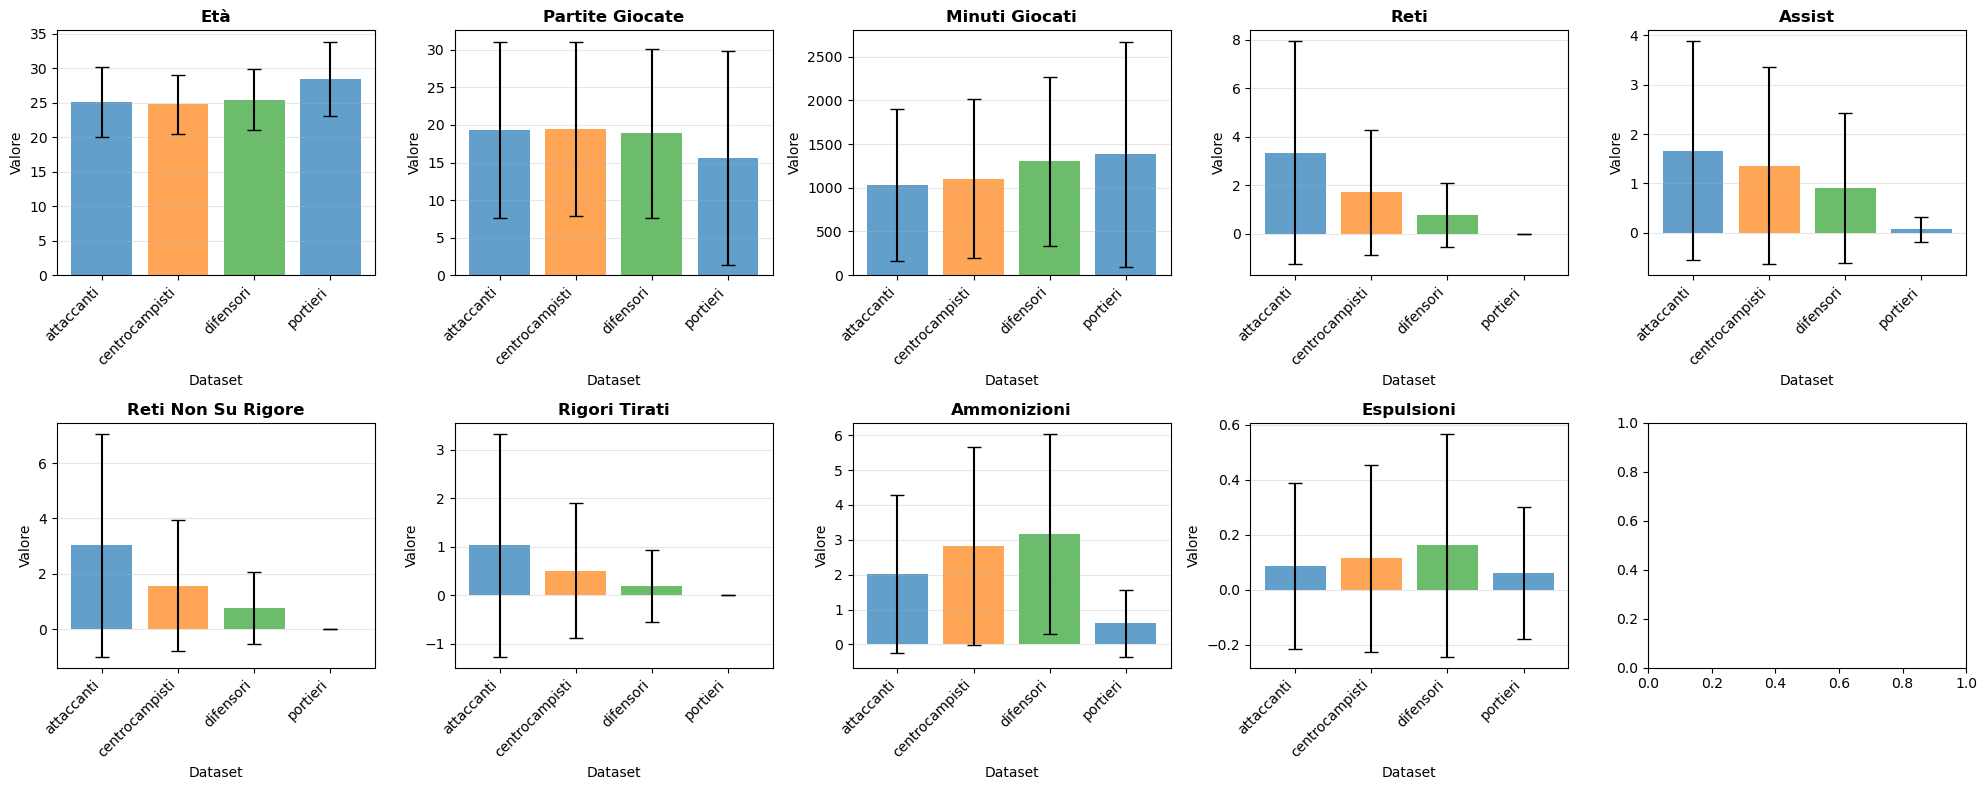


Tabella Riassuntiva (Media ± Std Dev):

Età:
  attaccanti          :    25.16 ±   5.07
  centrocampisti      :    24.77 ±   4.34
  difensori           :    25.44 ±   4.43
  portieri            :    28.48 ±   5.35

Partite Giocate:
  attaccanti          :    19.35 ±  11.69
  centrocampisti      :    19.45 ±  11.59
  difensori           :    18.87 ±  11.28
  portieri            :    15.57 ±  14.21

Minuti Giocati:
  attaccanti          :  1029.66 ± 867.76
  centrocampisti      :  1105.27 ± 913.45
  difensori           :  1301.36 ± 969.56
  portieri            :  1381.69 ± 1284.68

Reti:
  attaccanti          :     3.33 ±   4.59
  centrocampisti      :     1.70 ±   2.57
  difensori           :     0.77 ±   1.34
  portieri            :     0.00 ±   0.00

Assist:
  attaccanti          :     1.67 ±   2.21
  centrocampisti      :     1.36 ±   1.99
  difensori           :     0.91 ±   1.52
  portieri            :     0.07 ±   0.26

Reti Non Su Rigore:
  attaccanti          :     3.03 ±   4.03

In [11]:
features = ['Età', 'Partite Giocate', 'Minuti Giocati', 'Reti', 'Assist', 
            'Reti Non Su Rigore', 'Rigori Tirati', 'Ammonizioni', 'Espulsioni']

# Calcola medie e deviazioni standard
stats = []
for name, dataframes in dataframes.items():
    means = dataframes[features].mean()
    stds = dataframes[features].std()
    stats.append({
        'name': name,
        'means': means,
        'stds': stds
    })

# Crea il grafico
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, feature in enumerate(features):
    ax = axes[idx]
    
    # Prepara i dati per il grafico
    names = [s['name'] for s in stats]
    means = [s['means'][feature] for s in stats]
    stds = [s['stds'][feature] for s in stats]
    
    x = np.arange(len(names))
    
    # Crea bar plot con error bars
    bars = ax.bar(x, means, yerr=stds, capsize=5, alpha=0.7, 
                   color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    
    ax.set_xlabel('Dataset')
    ax.set_ylabel('Valore')
    ax.set_title(feature, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('confronto_features.png', dpi=300, bbox_inches='tight')
plt.show()

# Stampa anche una tabella riassuntiva
print("\nTabella Riassuntiva (Media ± Std Dev):")
print("=" * 80)
for feature in features:
    print(f"\n{feature}:")
    for s in stats:
        mean = s['means'][feature]
        std = s['stds'][feature]
        print(f"  {s['name']:20s}: {mean:8.2f} ± {std:6.2f}")

reti non su rigore: è molto simile a reti ma ha una deviazione standard un po' più bassa, quindi userò quello
assist
rigori tirati

In [12]:
df[['Ruolo1', 'Ruolo2']] = df['Ruolo?'].str.split(',', expand=True)
X=df[['Reti Non Su Rigore','Assist','Rigori Tirati']]
y=df[['Ruolo1']]

In [13]:
class Percettrone:
    """Percettrone semplice - nessun hidden layer"""
    def __init__(self, input_size, output_size, learning_rate=0.01):
        # Solo pesi diretti input->output
        self.W = np.random.randn(input_size, output_size) * 0.01
        self.b = np.zeros((1, output_size))
        self.lr = learning_rate
        
        # Metriche di training
        self.history = {
            'train_loss': [],
            'val_loss': [],
            'train_accuracy': [],
            'val_accuracy': [],
            'precision': [],
            'recall': [],
            'f1_score': []
        }
    
    def softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)
    
    def forward(self, X):
        # Calcolo diretto senza hidden layer
        self.z = np.dot(X, self.W) + self.b
        self.a = self.softmax(self.z)
        return self.a
    
    def backward(self, X, y, output):
        m = X.shape[0]
        
        # Gradiente per classificazione multi-classe
        dz = output - y
        dW = np.dot(X.T, dz) / m
        db = np.sum(dz, axis=0, keepdims=True) / m
        
        # Aggiornamento pesi
        self.W -= self.lr * dW
        self.b -= self.lr * db
    
    def compute_loss(self, y_true, y_pred):
        """Cross-entropy loss"""
        m = y_true.shape[0]
        loss = -np.sum(y_true * np.log(y_pred + 1e-8)) / m
        return loss
    
    def compute_accuracy(self, X, y):
        """Calcola accuracy - la predizione è corretta se matcha almeno una delle colonne"""
        predictions = self.forward(X)
        y_pred = np.argmax(predictions, axis=1)
        
        # Gestione sia one-hot che sparse labels
        if y.ndim == 1:
            # Se y è 1D (sparse), confronto diretto
            return np.mean(y_pred == y)
        
        # Se y è 2D (one-hot, possibilmente multi-label)
        correct = 0
        for i in range(len(y_pred)):
            # Trova tutte le classi valide per questa riga (dove y > 0 o y == 1)
            valid_classes = np.where(y[i] > 0)[0]
            # Se la predizione è in una delle classi valide, è corretta
            if len(valid_classes) > 0 and y_pred[i] in valid_classes:
                correct += 1
            elif len(valid_classes) == 0:
                # Se non ci sono classi valide, consideriamolo errato
                pass
        
        return correct / len(y_pred) if len(y_pred) > 0 else 0.0
    
    def compute_metrics(self, X, y):
        """Calcola precision, recall, f1-score considerando multi-label"""
        predictions = self.forward(X)
        y_pred = np.argmax(predictions, axis=1)
        
        # Gestione sia one-hot che sparse labels
        if y.ndim == 1:
            # Se y è 1D (sparse), usa direttamente
            y_true_filtered = y
            y_pred_filtered = y_pred
        else:
            # Se y è 2D (one-hot, possibilmente multi-label)
            # Per metriche standard, usa la prima classe valida come riferimento
            y_true = []
            for i in range(len(y)):
                valid_classes = np.where(y[i] > 0)[0]
                if len(valid_classes) > 0:
                    y_true.append(valid_classes[0])
                else:
                    y_true.append(-1)  # Nessuna classe valida
            y_true = np.array(y_true)
        
            # Rimuovi sample senza classe valida
            valid_idx = y_true != -1
            y_true_filtered = y_true[valid_idx]
            y_pred_filtered = y_pred[valid_idx]
        
        if len(y_true_filtered) == 0:
            return 0.0, 0.0, 0.0
        
        precision = precision_score(y_true_filtered, y_pred_filtered, average='macro', zero_division=0)
        recall = recall_score(y_true_filtered, y_pred_filtered, average='macro', zero_division=0)
        f1 = f1_score(y_true_filtered, y_pred_filtered, average='macro', zero_division=0)
        
        return precision, recall, f1
    
    def train(self, X_train, y_train, X_val, y_val, epochs=300, batch_size=32):
        n_samples = X_train.shape[0]
        
        for epoch in range(epochs):
            # Training
            indices = np.random.permutation(n_samples)
            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]
            
            epoch_train_loss = []
            
            for i in range(0, n_samples, batch_size):
                X_batch = X_shuffled[i:i+batch_size]
                y_batch = y_shuffled[i:i+batch_size]
                
                # Forward pass
                output = self.forward(X_batch)
                
                # Calcolo loss
                loss = self.compute_loss(y_batch, output)
                epoch_train_loss.append(loss)
                
                # Backward pass
                self.backward(X_batch, y_batch, output)
            
            # Salva metriche
            self.history['train_loss'].append(np.mean(epoch_train_loss))
            self.history['train_accuracy'].append(self.compute_accuracy(X_train, y_train))
            
            val_output = self.forward(X_val)
            self.history['val_loss'].append(self.compute_loss(y_val, val_output))
            self.history['val_accuracy'].append(self.compute_accuracy(X_val, y_val))
            
            precision, recall, f1 = self.compute_metrics(X_val, y_val)
            self.history['precision'].append(precision)
            self.history['recall'].append(recall)
            self.history['f1_score'].append(f1)
            
            if (epoch + 1) % 50 == 0:
                print(f"Epoch {epoch+1}/{epochs} - "
                      f"Train Loss: {self.history['train_loss'][-1]:.4f} - "
                      f"Val Loss: {self.history['val_loss'][-1]:.4f} - "
                      f"Val Acc: {self.history['val_accuracy'][-1]:.4f}")
    
    def predict(self, X):
        """Predizione sulle classi"""
        predictions = self.forward(X)
        return np.argmax(predictions, axis=1)


In [14]:
def compute_multilabel_accuracy(y_true, y_pred):
    """
    Calcola accuracy per multi-label classification
    
    Parameters:
    -----------
    y_true : array (n_samples, n_classes)
        Array one-hot dove ogni riga può avere più 1
        Es: [1, 1, 0, 0] → valide sia classe 0 che classe 1
    y_pred : array (n_samples,)
        Array con una predizione per sample
        Es: [0, 2, 1, ...] → predizioni singole
    
    Returns:
    --------
    accuracy : float
        Percentuale di predizioni corrette
    """
    correct = 0
    
    for i in range(len(y_pred)):
        # Trova tutte le classi valide (dove c'è un 1)
        valid_classes = np.where(y_true[i] > 0)[0]
        
        # Controlla se la predizione è in una delle classi valide
        if y_pred[i] in valid_classes:
            correct += 1
    
    return correct / len(y_pred)
def plot_training_history(model, smooth_window=10):
    """
    Plotta le metriche di training di un singolo modello
    
    Parameters:
    -----------
    model : oggetto modello con attributo history
        Il modello trainato che contiene le metriche in model.history
    smooth_window : int, default=10
        Dimensione della finestra per lo smoothing delle curve
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    metrics = [
        ('train_loss', 'Training Loss'),
        ('val_loss', 'Validation Loss'),
        ('val_accuracy', 'Validation Accuracy'),
        ('precision', 'Precision'),
        ('recall', 'Recall'),
        ('f1_score', 'F1-Score')
    ]
    
    for idx, (metric, title) in enumerate(metrics):
        row = idx // 3
        col = idx % 3
        ax = axes[row, col]
        
        # Verifica che la metrica esista
        if metric not in model.history:
            ax.text(0.5, 0.5, f'{metric} non disponibile', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(title)
            continue
        
        data = model.history[metric]
        
        # Plot dati raw (con trasparenza)
        ax.plot(data, 'o-', alpha=0.3, markersize=2, color='blue', label='results')
        
        # Plot smoothed
        if len(data) >= smooth_window:
            smoothed = uniform_filter1d(data, smooth_window)
            ax.plot(smoothed, '--', color='orange', linewidth=2, label='smooth')
        
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(title)
        ax.legend()
        ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()



In [15]:
class_map = {'Att': 0, 'Cen': 1, 'Dif': 2, 'Por': 3}
n_classes = 4

y = np.zeros((len(df), n_classes))
for i in range(len(df)):
    # Ruolo1
    if pd.notna(df.loc[i, 'Ruolo1']) and df.loc[i, 'Ruolo1'] in class_map:
        y[i, class_map[df.loc[i, 'Ruolo1']]] = 1
    
    # Ruolo2 (se esiste)
#    if 'Ruolo2' in df.columns:
#        if pd.notna(df.loc[i, 'Ruolo2']) and df.loc[i, 'Ruolo2'] in class_map:
#            y[i, class_map[df.loc[i, 'Ruolo2']]] = 1

In [16]:
y

array([[0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       ...,
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]])

In [17]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
    )
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42
    )
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [18]:
perc = Percettrone(
    input_size=3,
    output_size=4,
    learning_rate=0.01
)
perc.train(X_train, y_train, X_val, y_val, epochs=1000, batch_size=32)


Epoch 50/1000 - Train Loss: 1.1682 - Val Loss: 1.1717 - Val Acc: 0.4353
Epoch 100/1000 - Train Loss: 1.1597 - Val Loss: 1.1628 - Val Acc: 0.4263
Epoch 150/1000 - Train Loss: 1.1560 - Val Loss: 1.1585 - Val Acc: 0.4286
Epoch 200/1000 - Train Loss: 1.1530 - Val Loss: 1.1557 - Val Acc: 0.4286
Epoch 250/1000 - Train Loss: 1.1514 - Val Loss: 1.1536 - Val Acc: 0.4286
Epoch 300/1000 - Train Loss: 1.1501 - Val Loss: 1.1520 - Val Acc: 0.4286
Epoch 350/1000 - Train Loss: 1.1491 - Val Loss: 1.1507 - Val Acc: 0.4286
Epoch 400/1000 - Train Loss: 1.1479 - Val Loss: 1.1497 - Val Acc: 0.4286
Epoch 450/1000 - Train Loss: 1.1473 - Val Loss: 1.1488 - Val Acc: 0.4286
Epoch 500/1000 - Train Loss: 1.1464 - Val Loss: 1.1481 - Val Acc: 0.4286
Epoch 550/1000 - Train Loss: 1.1459 - Val Loss: 1.1474 - Val Acc: 0.4286
Epoch 600/1000 - Train Loss: 1.1453 - Val Loss: 1.1469 - Val Acc: 0.4286
Epoch 650/1000 - Train Loss: 1.1452 - Val Loss: 1.1464 - Val Acc: 0.4286
Epoch 700/1000 - Train Loss: 1.1448 - Val Loss: 1.14

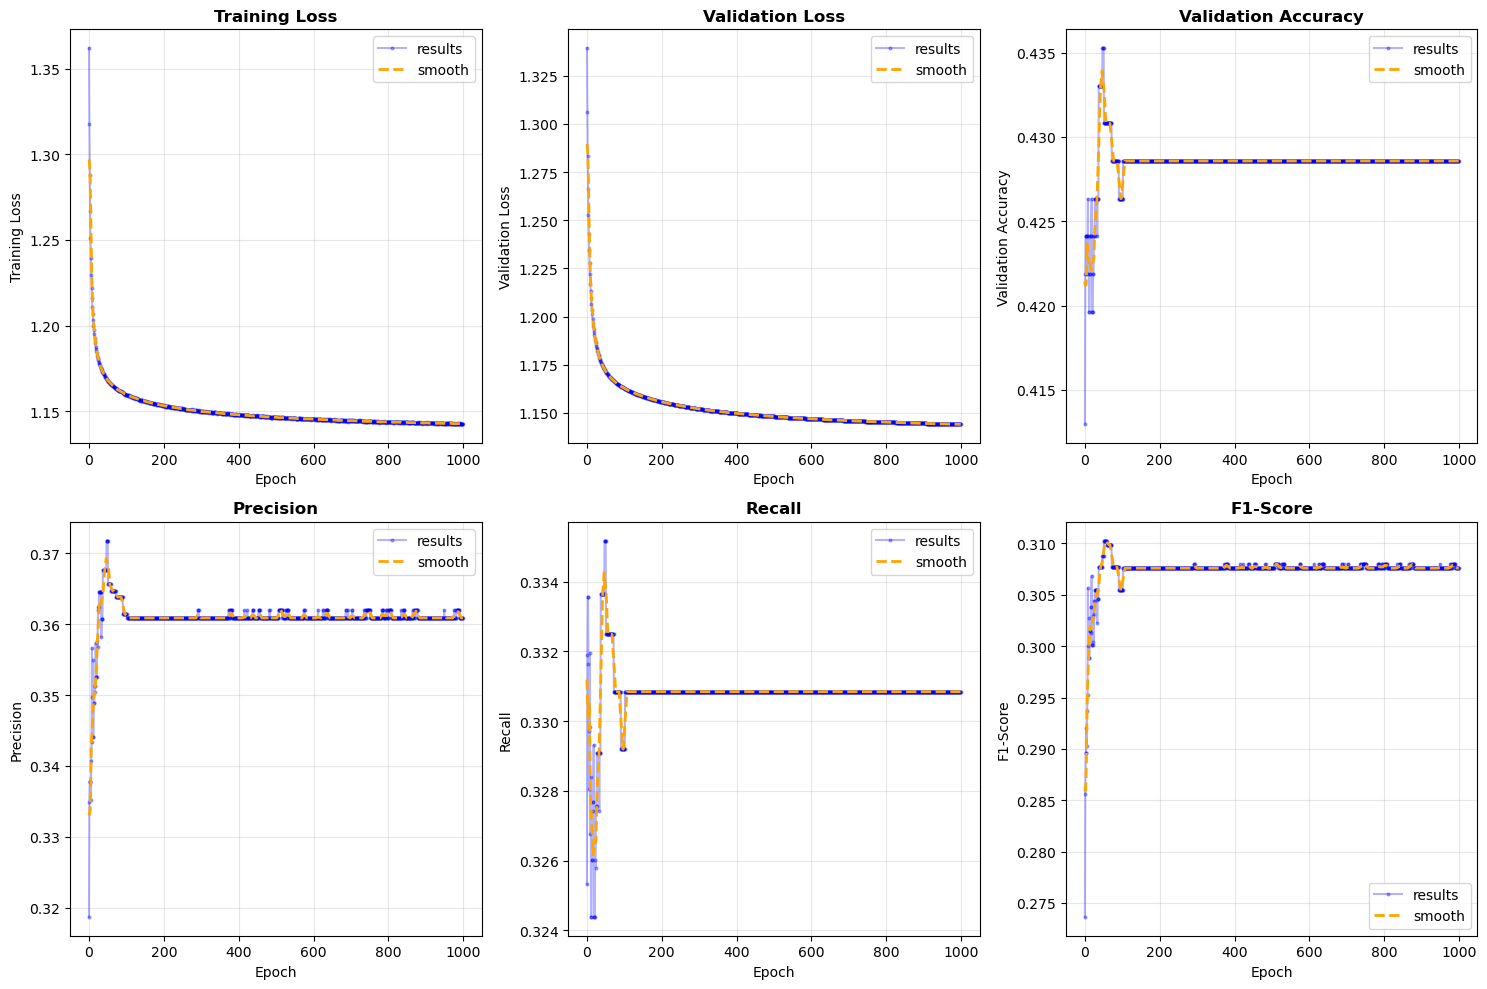

In [19]:
plot_training_history(perc)

In [20]:
y_pred=perc.predict(X_test)
accuracy = compute_multilabel_accuracy(y_test, y_pred)
print(f"Accuracy multi-label: {accuracy:.4f}")

Accuracy multi-label: 0.4819


In [21]:
class RegressioneLogistica:
    """Regressione Logistica multi-classe con funzionalità complete"""
    def __init__(self, input_size, output_size, learning_rate=0.01, regularization=0.0):
        """
        Parameters:
        -----------
        input_size : int
            Numero di features in input
        output_size : int
            Numero di classi
        learning_rate : float
            Tasso di apprendimento
        regularization : float
            Parametro di regolarizzazione L2 (0 = nessuna regolarizzazione)
        """
        # Inizializzazione pesi (piccoli valori random)
        self.W = np.random.randn(input_size, output_size) * 0.01
        self.b = np.zeros((1, output_size))
        self.lr = learning_rate
        self.reg = regularization
        
        # Metriche di training
        self.history = {
            'train_loss': [],
            'val_loss': [],
            'train_accuracy': [],
            'val_accuracy': [],
            'precision': [],
            'recall': [],
            'f1_score': []
        }
    
    def softmax(self, x):
        """Funzione softmax per classificazione multi-classe"""
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)
    
    def forward(self, X):
        """Forward pass: calcola le probabilità per ogni classe"""
        self.z = np.dot(X, self.W) + self.b
        self.a = self.softmax(self.z)
        return self.a
    
    def backward(self, X, y, output):
        """Backward pass: calcola gradienti e aggiorna pesi"""
        m = X.shape[0]
        
        # Gradiente della loss rispetto ai pesi
        dz = output - y
        dW = np.dot(X.T, dz) / m
        db = np.sum(dz, axis=0, keepdims=True) / m
        
        # Aggiungi regolarizzazione L2 (se presente)
        if self.reg > 0:
            dW += (self.reg / m) * self.W
        
        # Aggiornamento pesi con gradient descent
        self.W -= self.lr * dW
        self.b -= self.lr * db
    
    def compute_loss(self, y_true, y_pred):
        """
        Cross-entropy loss con opzionale regolarizzazione L2
        
        Loss = -1/m * sum(y * log(y_pred)) + lambda/2m * sum(W^2)
        """
        m = y_true.shape[0]
        
        # Cross-entropy loss
        ce_loss = -np.sum(y_true * np.log(y_pred + 1e-8)) / m
        
        # Regolarizzazione L2 (penalizza pesi grandi)
        if self.reg > 0:
            l2_loss = (self.reg / (2 * m)) * np.sum(self.W ** 2)
            return ce_loss + l2_loss
        
        return ce_loss
    
    def compute_accuracy(self, X, y):
        """Calcola accuracy - supporta multi-label"""
        predictions = self.forward(X)
        y_pred = np.argmax(predictions, axis=1)
        
        # Controlla se y è multi-label (può avere più 1 per riga)
        if y.ndim == 2 and y.shape[1] > 1:
            correct = 0
            for i in range(len(y_pred)):
                valid_classes = np.where(y[i] > 0)[0]
                if y_pred[i] in valid_classes:
                    correct += 1
            return correct / len(y_pred)
        else:
            # Single-label
            return np.mean(y_pred == y)
    
    def compute_metrics(self, X, y):
        """Calcola precision, recall, f1-score"""
        predictions = self.forward(X)
        y_pred = np.argmax(predictions, axis=1)
        
        # Gestione multi-label: usa la prima classe valida
        if y.ndim == 2 and y.shape[1] > 1:
            y_true = []
            for i in range(len(y)):
                valid_classes = np.where(y[i] > 0)[0]
                if len(valid_classes) > 0:
                    y_true.append(valid_classes[0])
                else:
                    y_true.append(-1)
            y_true = np.array(y_true)
            
            # Rimuovi sample senza classe valida
            valid_idx = y_true != -1
            y_true_filtered = y_true[valid_idx]
            y_pred_filtered = y_pred[valid_idx]
        else:
            y_true_filtered = y
            y_pred_filtered = y_pred
        
        if len(y_true_filtered) == 0:
            return 0.0, 0.0, 0.0
        
        precision = precision_score(y_true_filtered, y_pred_filtered, average='macro', zero_division=0)
        recall = recall_score(y_true_filtered, y_pred_filtered, average='macro', zero_division=0)
        f1 = f1_score(y_true_filtered, y_pred_filtered, average='macro', zero_division=0)
        
        return precision, recall, f1
    
    def train(self, X_train, y_train, X_val, y_val, epochs=300, batch_size=32, verbose=True):
        """
        Training del modello con mini-batch gradient descent
        
        Parameters:
        -----------
        X_train : array (n_samples, n_features)
            Dati di training
        y_train : array (n_samples, n_classes) o (n_samples,)
            Labels di training (one-hot o sparse)
        X_val : array
            Dati di validation
        y_val : array
            Labels di validation
        epochs : int
            Numero di epoche
        batch_size : int
            Dimensione del batch
        verbose : bool
            Se True, stampa progress ogni 50 epoche
        """
        n_samples = X_train.shape[0]
        
        for epoch in range(epochs):
            # Shuffle dei dati ad ogni epoca
            indices = np.random.permutation(n_samples)
            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]
            
            epoch_train_loss = []
            
            # Mini-batch training
            for i in range(0, n_samples, batch_size):
                X_batch = X_shuffled[i:i+batch_size]
                y_batch = y_shuffled[i:i+batch_size]
                
                # Forward pass
                output = self.forward(X_batch)
                
                # Calcolo loss
                loss = self.compute_loss(y_batch, output)
                epoch_train_loss.append(loss)
                
                # Backward pass
                self.backward(X_batch, y_batch, output)
            
            # Salva metriche di training
            self.history['train_loss'].append(np.mean(epoch_train_loss))
            self.history['train_accuracy'].append(self.compute_accuracy(X_train, y_train))
            
            # Validation
            val_output = self.forward(X_val)
            self.history['val_loss'].append(self.compute_loss(y_val, val_output))
            self.history['val_accuracy'].append(self.compute_accuracy(X_val, y_val))
            
            # Metriche aggiuntive
            precision, recall, f1 = self.compute_metrics(X_val, y_val)
            self.history['precision'].append(precision)
            self.history['recall'].append(recall)
            self.history['f1_score'].append(f1)
            
            # Stampa progress
            if verbose and (epoch + 1) % 50 == 0:
                print(f"Epoch {epoch+1}/{epochs} - "
                      f"Train Loss: {self.history['train_loss'][-1]:.4f} - "
                      f"Val Loss: {self.history['val_loss'][-1]:.4f} - "
                      f"Val Acc: {self.history['val_accuracy'][-1]:.4f}")
    
    def predict(self, X):
        """
        Predizione delle classi
        
        Returns:
        --------
        y_pred : array (n_samples,)
            Classi predette (0, 1, 2, ...)
        """
        predictions = self.forward(X)
        return np.argmax(predictions, axis=1)
    
    def predict_proba(self, X):
        """
        Predizione delle probabilità per ogni classe
        
        Returns:
        --------
        proba : array (n_samples, n_classes)
            Probabilità per ogni classe
        """
        return self.forward(X)
    
    def plot_training_history(self, smooth_window=10):
        """Plotta le metriche di training"""
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        metrics = [
            ('train_loss', 'Training Loss'),
            ('val_loss', 'Validation Loss'),
            ('val_accuracy', 'Validation Accuracy'),
            ('precision', 'Precision'),
            ('recall', 'Recall'),
            ('f1_score', 'F1-Score')
        ]
        
        for idx, (metric, title) in enumerate(metrics):
            row = idx // 3
            col = idx % 3
            ax = axes[row, col]
            
            data = self.history[metric]
            
            # Plot dati raw
            ax.plot(data, 'o-', alpha=0.3, markersize=2, color='blue', label='results')
            
            # Plot smoothed
            if len(data) >= smooth_window:
                smoothed = uniform_filter1d(data, smooth_window)
                ax.plot(smoothed, '--', color='orange', linewidth=2, label='smooth')
            
            ax.set_title(title, fontweight='bold')
            ax.set_xlabel('Epoch')
            ax.set_ylabel(title)
            ax.legend()
            ax.grid(alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('logistic_regression_training.png', dpi=300, bbox_inches='tight')
        plt.show()

In [22]:
logreg = RegressioneLogistica(
    input_size=3,
    output_size=4,
    learning_rate=0.1
)
logreg.train(X_train, y_train, X_val, y_val, epochs=1000, batch_size=32)


Epoch 50/1000 - Train Loss: 1.1493 - Val Loss: 1.1480 - Val Acc: 0.4353
Epoch 100/1000 - Train Loss: 1.1447 - Val Loss: 1.1458 - Val Acc: 0.4263
Epoch 150/1000 - Train Loss: 1.1427 - Val Loss: 1.1420 - Val Acc: 0.4442
Epoch 200/1000 - Train Loss: 1.1425 - Val Loss: 1.1414 - Val Acc: 0.4308
Epoch 250/1000 - Train Loss: 1.1412 - Val Loss: 1.1407 - Val Acc: 0.4353
Epoch 300/1000 - Train Loss: 1.1414 - Val Loss: 1.1392 - Val Acc: 0.4353
Epoch 350/1000 - Train Loss: 1.1409 - Val Loss: 1.1417 - Val Acc: 0.4263
Epoch 400/1000 - Train Loss: 1.1408 - Val Loss: 1.1395 - Val Acc: 0.4308
Epoch 450/1000 - Train Loss: 1.1403 - Val Loss: 1.1408 - Val Acc: 0.4286
Epoch 500/1000 - Train Loss: 1.1394 - Val Loss: 1.1399 - Val Acc: 0.4330
Epoch 550/1000 - Train Loss: 1.1398 - Val Loss: 1.1390 - Val Acc: 0.4375
Epoch 600/1000 - Train Loss: 1.1394 - Val Loss: 1.1401 - Val Acc: 0.4308
Epoch 650/1000 - Train Loss: 1.1395 - Val Loss: 1.1399 - Val Acc: 0.4286
Epoch 700/1000 - Train Loss: 1.1404 - Val Loss: 1.13

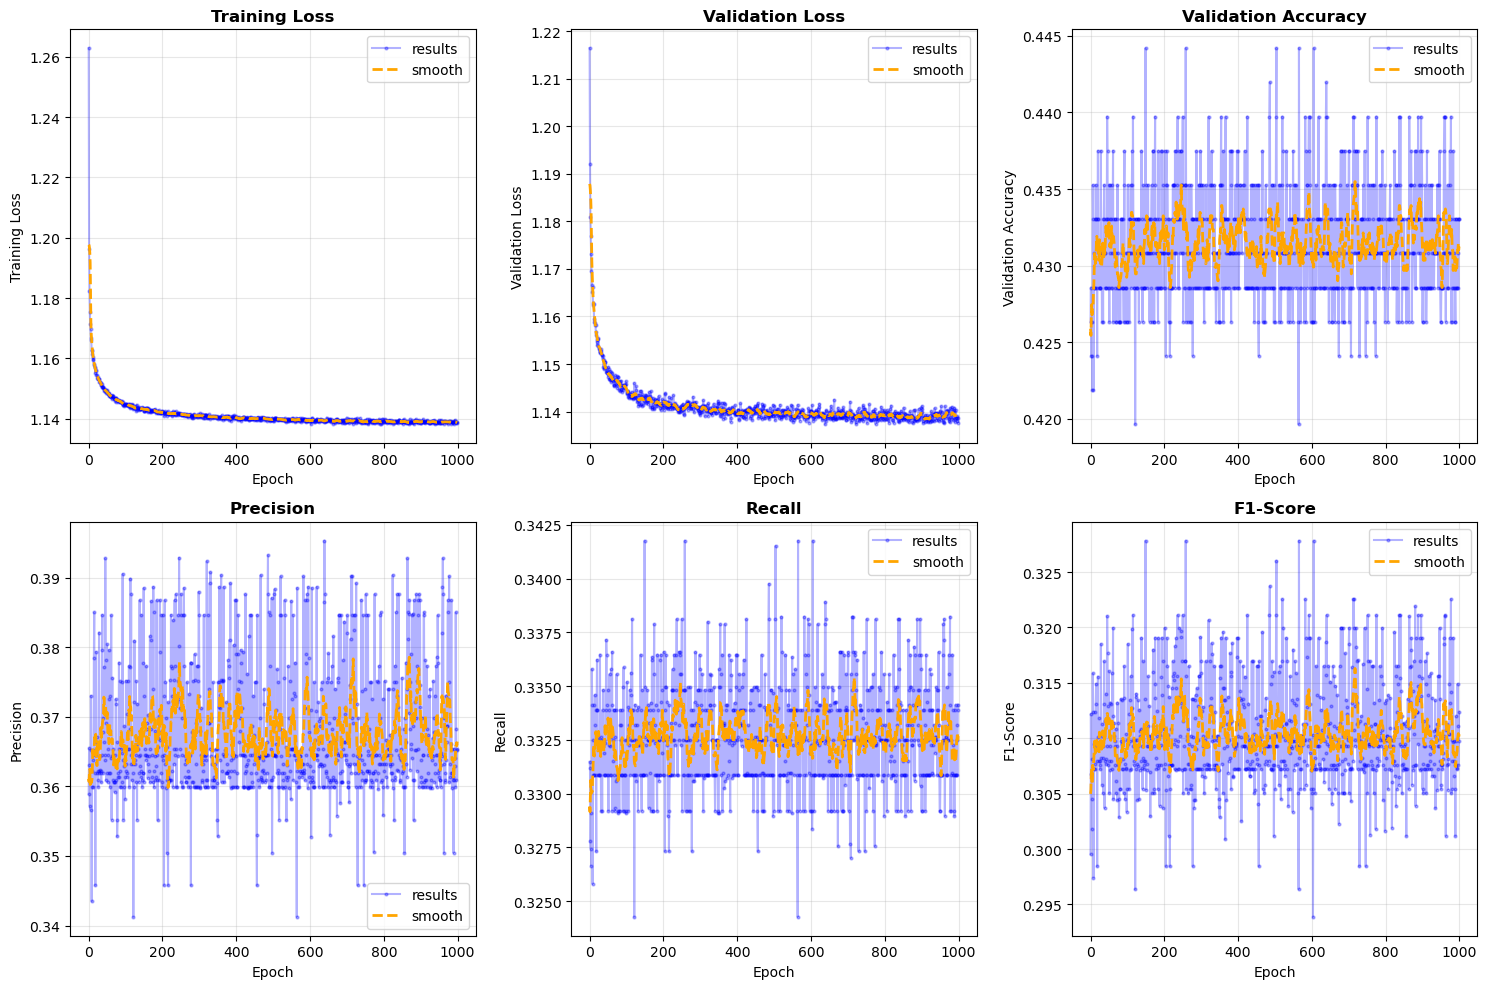

In [23]:
plot_training_history(logreg)

In [24]:
y_pred=logreg.predict(X_test)
accuracy = compute_multilabel_accuracy(y_test, y_pred)
print(f"Accuracy multi-label: {accuracy:.4f}")

Accuracy multi-label: 0.4940


In [25]:
y_pred

array([2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 1, 2, 2, 2, 2, 1, 2,
       1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 0, 0, 2, 0, 1, 2, 1, 1, 2,
       0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 0, 2, 1, 2, 2, 2, 1, 0,
       2, 2, 1, 2, 0, 2, 2, 2, 2, 2, 2, 1, 1, 1, 0, 2, 2, 2, 1, 0, 2, 2,
       1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 1, 0, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2,
       2, 2, 0, 2, 0, 2, 2, 1, 2, 1, 2, 2, 0, 1, 1, 0, 0, 2, 2, 2, 2, 1,
       0, 2, 0, 2, 2, 2, 2, 1, 1, 2, 1, 2, 2, 1, 1, 2, 1, 2, 2, 2, 2, 2,
       2, 2, 2, 1, 2, 0, 2, 2, 2, 2, 0, 1, 2, 0, 2, 1, 2, 0, 1, 1, 0, 1,
       2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 0, 2, 2, 2, 2, 1, 0, 0, 1, 2, 2,
       2, 2, 1, 2, 1, 1, 1, 2, 2, 2, 2, 0, 1, 2, 1, 2, 2, 1, 2, 2, 1, 0,
       2, 2, 1, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 0, 1, 2, 2,
       2, 2, 0, 2, 2, 2, 2], dtype=int64)